### **Introduction**

This is a Data Science project intended to further polish my skills as a future Machine Learning Engineer. In this project I will practice creating and Assessing the Linear Regression model I have built, using Statistics knowledge as well as detailed Statistical and Logical approaches to enhance Model Efficiency in the Prediction of Californian House Prices using the [California Housing Price dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices).

In this Multiple Linear Regression Analysis steps will be followed as below.

1. Collection of data
2. Cleaning and Preproccessing Data
3. Checking if Data is suitable for Mutlitiple Linear Regression
4. Checking if model follows the Preliminary Assumptions
5. Final Validation and Interpretation

Then Model is ready to be deployed!

### **Importing Libraries**

In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor 

### **Importing data**

In [325]:
df = pd.read_csv("data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### **Exploratory Data Analysis (EDA) and Data Cleaning**

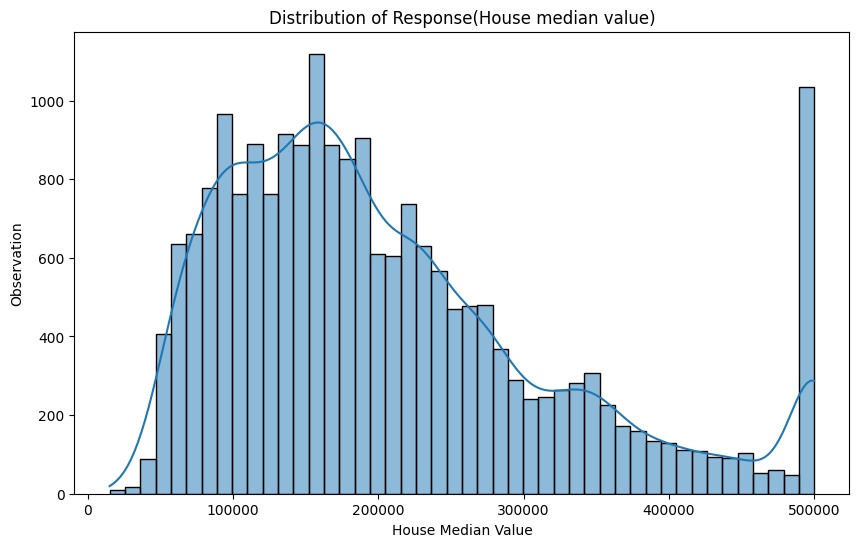

In [326]:
#looking at our data's distribution briefly
plt.figure(figsize=(10,6))
sns.histplot(df["median_house_value"],kde = True)
plt.title("Distribution of Response(House median value)")
plt.xlabel("House Median Value")
plt.ylabel("Observation")
plt.show()

** As we can see there are clear outliers, but we will access this later in our Model Adequacy Checking

In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Notice that total_bedrooms has missing values with only 20433 non-null instead of 20640 we will then check the exact number and percentage of missing values to see if it is significant enough to drop the variable (toatl_bedrooms).

In [328]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [329]:
(df.isna().sum()/len(df))*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

at a 1.0029 percent, missing vals arent significant enough to drop entire variable so we drop rows instead

In [330]:
df.shape

(20640, 10)

In [331]:
df = df.dropna()
df.shape

(20433, 10)

although unnecessary for Machine learning but it is best pratice in Data cleaning to change float data types that shouldnt be, to integers

In [332]:
cols = df.columns[2:7] #housing_median_age until households
df[cols] = df[cols].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  int64  
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.7+ MB


### **One-Hot-Encoding for "ocean_proximity" variable**

In [333]:
ocean_proximity_dummies = pd.get_dummies(df["ocean_proximity"],"ocean_prox")
ocean_proximity_dummies.head()

,ocean_prox_<1H OCEAN,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,True,False


In [334]:
ocean_proximity_dummies = ocean_proximity_dummies.astype(int) # change from bool to int
ocean_proximity_dummies.head()

,ocean_prox_<1H OCEAN,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0


To prevent Multicollinearity caused by creating dummy variables (so called the "dummy trap") we must drop at least one of the created dummy variables

In [335]:
ocean_proximity_dummies = ocean_proximity_dummies.iloc[:, 1:] #excluded 1st column
ocean_proximity_dummies.head()

,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [336]:
df = df.drop(df.columns[-1], axis=1) #dropping original ocear_proximity variable
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374,845,330,1.5603,78100.0
20636,-121.21,39.49,18,697,150,356,114,2.5568,77100.0
20637,-121.22,39.43,17,2254,485,1007,433,1.7000,92300.0
20638,-121.32,39.43,18,1860,409,741,349,1.8672,84700.0


In [337]:
#concatonating dummy variables with main dataframe
df = pd.concat([df,ocean_proximity_dummies],axis=1)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0,0,0,1,0


### **Creating Model and Assessing Model Assumptions**

In the multiple Linear Regression model there are 4 main Preliminary assumptions

1. **Multicollinearity**: *Independent variables(Xi) should NOT be highly correlated with each other.*
2. **Linearity**: *Relationship between predictors(Xi) and Response(Yi) are linear.*
3. **Independence**: *Observations are independent of each other.*
4. **Homoscedasticity & Normality**: *Residuals have a normal distribution with mean of 0 and constant variance. *

Since our Dependent variables are known we will start by checking if our dependent variables have **Multicollinearity (Assumption 1)**

<function matplotlib.pyplot.show(close=None, block=None)>

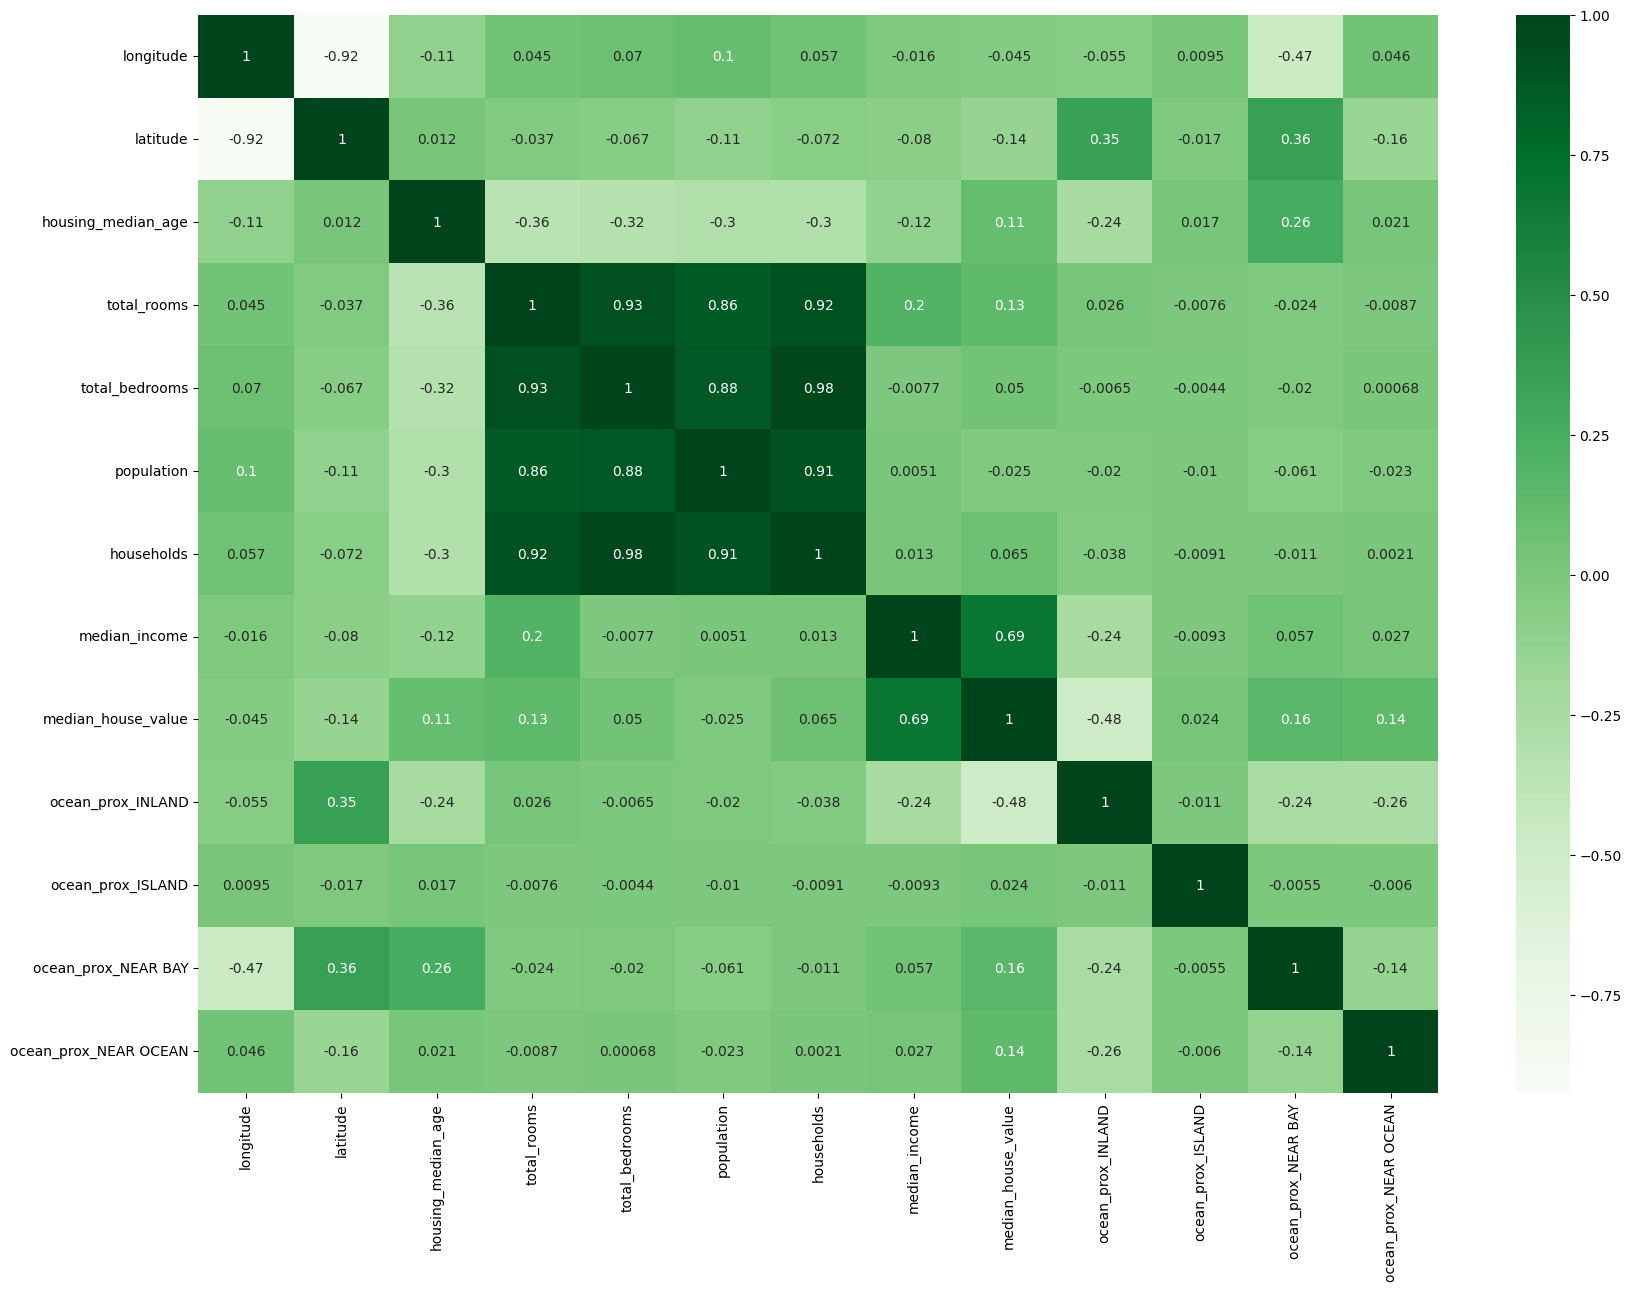

In [338]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,14))
sns.heatmap(corr,annot=True,cmap="Greens")
plt.show

As we can see from the correlation heatmap there is multicollinearity occurring within 4 variables: total_bedrooms, total rooms, households, population in order to decide which column to drop we check the Variance Inflation Factor(VIF) parellel with their respective R squared values.

In [339]:

#adding a function to get VIF table with R squared to observe Multicollinearity


def get_VIF_table(df, target):
    VIF = pd.DataFrame()
    X = df.select_dtypes(include="number")
    X = X.drop(columns=[target])
    X = sm.add_constant(X) # adding like a "1" to our X matrix
    VIF["Variables"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF["R_squared"] = [ None if col == "const" else df[col].corr(df[target])**2 for col in X.columns]
    return VIF


In [340]:
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,33578.822227,NaN
1,longitude,18.090772,0.002061
2,latitude,19.969176,0.020920
3,housing_median_age,1.323622,0.011328
4,total_rooms,12.966422,0.017767
5,total_bedrooms,36.309883,0.002469
6,population,6.446223,0.000640
7,households,35.173375,0.004211
8,median_income,1.786367,0.473833
9,ocean_prox_INLAND,2.859799,0.235018


Since total_bedrooms has a significant VIF (>10) and a low Coefficient correlation we drop the variable and see how the VIF table changes

In [341]:
df = df.drop(columns=["total_bedrooms"])
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,33069.229997,NaN
1,longitude,17.881188,0.002061
2,latitude,19.841726,0.020920
3,housing_median_age,1.319270,0.011328
4,total_rooms,9.753562,0.017767
5,population,6.018213,0.000640
6,households,11.827681,0.004211
7,median_income,1.567640,0.473833
8,ocean_prox_INLAND,2.843861,0.235018
9,ocean_prox_ISLAND,1.001721,0.000553


The deletion of the "total_bedrooms" variable has significantly affected the VIF of other Variables. Variables that appear to have a high VIF are "latitude", "longtitude", and "households". 

We are going to be keeping Latitude and Longtitude Variables because they're high VIF mostly comes from correlation between them,not to mention that they are also meaningful geographical variables. As for households, given its high correlation to population, nnot to mention that households has more correlation to the response than population, it is in our best interest to drop "population" instead.

In [342]:
df = df.drop(columns=["population"])
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,32984.308064,NaN
1,longitude,17.809368,0.002061
2,latitude,19.703697,0.020920
3,housing_median_age,1.319047,0.011328
4,total_rooms,9.431542,0.017767
5,households,8.972459,0.004211
6,median_income,1.547163,0.473833
7,ocean_prox_INLAND,2.843243,0.235018
8,ocean_prox_ISLAND,1.001586,0.000553
9,ocean_prox_NEAR BAY,1.553475,0.025768


The variables now have little to no Multicollinearity, successfully satisfying the 1st Assumption: No Multicollinearity

Next we create our model and then check the rest of the assumtions.

In [343]:
df["median_house_value"].mean()

np.float64(206864.41315519012)